<a href="https://colab.research.google.com/github/max-power-126/lab1_FFNN/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from csv import reader
import time
from torch.utils.data import TensorDataset, DataLoader

# Task 1 – Preprocessing

In [3]:

# D= length avg 3,E=max length 4,F=bytes 5,J=inter arrival time 9,K=packet length 10


data = pd.read_csv("dataset_lab_1.csv",encoding="utf-8")
# Modo corretto ed efficiente in pandas per filtrare i valori uguali a 0 nelle colonne desiderate
rawdata_size= data.shape
######################################## Missing and Duplicate #############################

print(f"dati iniziali",data.shape)
#drop NaN

data.dropna(inplace=True)

print(f"dati No NaN",data.shape)

# Definiamo le colonne che non devono contenere zeri
columns_to_filter = [
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean'
]

# Creiamo una maschera booleana: per ogni riga, tutte le colonne specificate devono essere diverse da 0
# (data[col] != 0).all(axis=1) verifica che la condizione sia True per TUTTE le colonne selezionate


mask = (data[columns_to_filter] != 0.0).all(axis=1)


# Applichiamo la maschera per ottenere il dataset pulito
data_cleaned = data[mask].copy()

modified_size=data_cleaned.shape

print(f"data filtered= {modified_size}")

data_cleaned.drop_duplicates(inplace=True,keep="first")

print(f"data no duplicate= {data_cleaned.shape}")

# Mostriamo la differenza di righe prima e dopo la pulizia

# 1. Rimuoviamo i valori NaN dal dataset finale


# 2. Rimuoviamo i valori infiniti (inf e -inf)
# Selezioniamo solo le colonne numeriche per verificare la presenza di infiniti
numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns
is_infinite = np.isinf(data_cleaned[numeric_cols]).any(axis=1)

# Teniamo solo le righe che NON contengono infiniti
data_cleaned_final = data_cleaned[~is_infinite]

print(f"data no inf= {data_cleaned_final.shape}")


#############################Encoded######################################

label_encoder = LabelEncoder()
data_cleaned_final['Label'] = label_encoder.fit_transform(data_cleaned_final['Label'])

data_choosed=data_cleaned_final.copy()

########################################### Split #############################

## train = 60 %, validation = 20 % , test=20%

# Split the dataset
X = data_choosed[['Flow Duration', 'Flow IAT Mean', 'Fwd PSH Flags',
       'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Bytes/s',
       'Down/Up Ratio', 'SYN Flag Count', 'Fwd Packet Length Mean',
       'Fwd IAT Std', 'Packet Length Mean', 'Fwd Packet Length Max',
       'Subflow Fwd Packets', 'Flow Packets/s', 'Total Fwd Packets',
       'Destination Port']].values
y = data_choosed['Label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



#################### Scaling ################################################
# Standardize the features
scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_val_S = scaler.transform(X_val)
X_test_S = scaler.transform(X_test)

print(y_train)
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

########################################################################


dati iniziali (31507, 17)
dati No NaN (31487, 17)
data filtered= (23773, 17)
data no duplicate= (23280, 17)
data no inf= (23280, 17)
[2 3 0 ... 0 0 2]


In [4]:
# @title
# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.show()
# plt.close()

# fig, ax = plt.subplots(figsize=(10,5))
# plt.scatter(x=data["Feature_1"].values,
#             y=data["Feature_2"].values,
#             c=data["Label"].values,
#             cmap=plt.cm.RdYlBu)
# plt.xlim(-2,2)
# plt.ylim(-2,2)
# plt.show()
# plt.close()

# Task 2 – Your first network

## Task 2A

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"The device is set to: {device}")

The device is set to: cuda


In [6]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [7]:
# Define the neural network
class ffnn(nn.Module):
    def __init__(self, input_size, output_size):
        super(ffnn, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_width)
        self.fc2 = nn.Linear(hidden_width, output_size)
        self.relu = activation_function()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [8]:
def training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, num_epochs, min_delta = None, patience = None):
  start_time = time.time()

  train_losses = []
  val_losses = []

  best_val_loss = float('inf')
  trigger_times = 0
  best_model_state = None
  for epoch in range(num_epochs):
    train_loss = 0
    val_loss = 0
    model.train()
    for batch_X, batch_y in train_loader:
      batch_X, batch_y = batch_X.to(device), batch_y.to(device)
      optimizer.zero_grad()
      outputs = model(batch_X)
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()
      train_loss += loss.item() * batch_X.size(0)
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    with torch.no_grad():
      for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        val_outputs = model(batch_X)
        loss = criterion(val_outputs, batch_y)
        val_loss += loss.item() * batch_X.size(0)
      val_loss /= len(val_dataset)
      val_losses.append(val_loss)

    if (epoch + 1) % 20 == 0:
      print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}')

    if min_delta is not None:
      if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        trigger_times = 0
      else:
        trigger_times += 1
        if trigger_times >= patience:
          print(f"Early stopping at epoch {epoch+1} (best val loss: {best_val_loss:.6f})")
          break
    if best_model_state is not None:
      model.load_state_dict(best_model_state)

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  plt.figure(figsize=(10, 5))
  plt.plot(train_losses, label='Train Loss')
  plt.plot(val_losses, label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss')
  plt.legend()
  plt.show()

  return

In [9]:
def testing_model(model, dataloader, device):
  start_time = time.time()

  model.eval()
  all_labels = []
  all_predictions = []

  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      _, predicted = torch.max(outputs, 1)
      all_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predicted.cpu().numpy())
  accuracy = accuracy_score(all_labels, all_predictions) * 100

  end_time = time.time()
  elapsed_time = end_time - start_time
  print(f'The function took {elapsed_time:.4f} seconds to execute.')

  return accuracy


In [10]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [11]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0600, Val Loss: 0.0614
Epoch 40/100, Train Loss: 0.0401, Val Loss: 0.0422
Epoch 60/100, Train Loss: 0.0285, Val Loss: 0.0312
Epoch 80/100, Train Loss: 0.0244, Val Loss: 0.0269
Epoch 100/100, Train Loss: 0.0221, Val Loss: 0.0253
The function took 59.6705 seconds to execute.


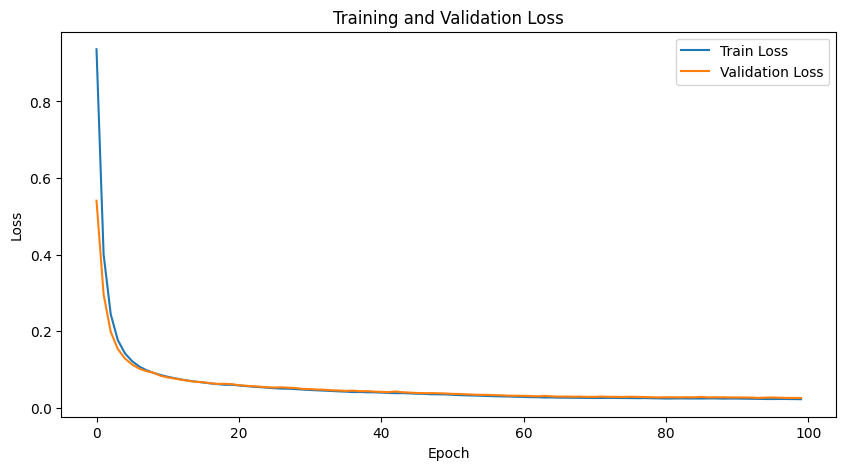

In [12]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [13]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.1738,  0.5521, -0.2149,  ...,  0.7622, -0.2236, -0.0311],
        [-0.1225, -0.3822, -0.3421,  ..., -0.1130, -0.0243, -0.0016],
        [ 0.2156,  0.0547, -0.0326,  ...,  0.2652,  0.3301,  0.2091],
        ...,
        [-0.2134, -0.0505, -0.1252,  ...,  0.4475, -0.2378,  0.2194],
        [-0.0843, -0.0646, -0.1575,  ...,  0.2341,  0.0751,  0.1846],
        [ 0.3635, -0.3759, -0.3465,  ...,  0.0195, -0.0406, -0.2750]],
       device='cuda:0')
Learned biases: tensor([ 4.9060e-01,  1.6441e-01, -1.2358e-01,  2.6779e-01,  2.8418e-01,
         3.6606e-01,  5.8563e-03,  3.5919e-01,  1.1875e-01, -2.3151e-01,
        -2.2597e-02,  7.3730e-03,  3.1154e-01,  1.5191e-01,  2.3867e-01,
        -3.9303e-01,  1.8537e-01, -1.9137e-01,  4.0373e-02,  1.7378e-01,
        -4.1449e-02,  2.0256e-01,  1.1347e-01,  3.5059e-02,  4.6333e-01,
         1.1274e-01, -2.0804e-02,  2.1525e-01,  4.1856e-01,  1.8912e-01,
         2.2748e-01, -2.1437e-02,  1.1765e-01,  2.1020e-02,  1.5796e-01

In [14]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.3582 seconds to execute.
The function took 0.1196 seconds to execute.
The function took 0.1102 seconds to execute.
Train Accuracy: 99.4917
Validation Accuracy: 99.4631
Test Accuracy: 99.3557


## Task 2B

### S1 – no feature scaling

In [15]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-4
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [16]:
# Convert data to PyTorch tensors and send to CUDA
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

In [17]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [18]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 2639.4505, Val Loss: 1009.4623
Early stopping at epoch 24 (best val loss: 740.434312)
The function took 20.2816 seconds to execute.


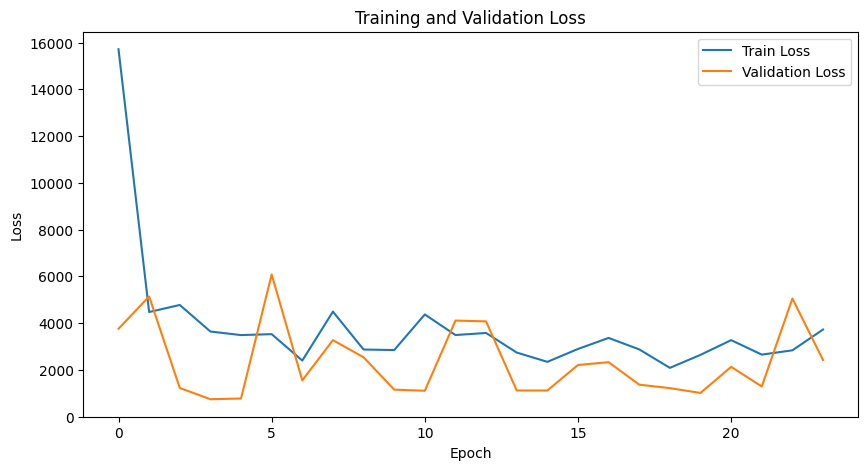

In [19]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [20]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[-0.0721,  0.0630, -0.2507,  ...,  0.0418, -0.1607, -0.1906],
        [-0.1789,  0.0583, -0.1697,  ...,  0.1090,  0.2625, -0.1852],
        [-0.1884, -0.2284,  0.0771,  ...,  0.1842, -0.0083, -0.1631],
        ...,
        [ 0.1165, -0.0575,  0.2937,  ..., -0.0805, -0.0729,  0.1946],
        [ 0.0626, -0.1911, -0.1709,  ...,  0.0804, -0.0416,  0.0993],
        [ 0.0018, -0.1612, -0.1309,  ..., -0.0385,  0.0383, -0.1873]],
       device='cuda:0')
Learned biases: tensor([-0.0723,  0.0886, -0.0532,  0.0071,  0.4241, -0.0998, -0.3232, -0.0045,
         0.1911,  0.0040,  0.1856,  0.1501, -0.0780,  0.2101,  0.2555, -0.2389,
         0.1046, -0.0418, -0.0090,  0.2804,  0.0698,  0.4822,  0.0482,  0.1706,
        -0.1433,  0.4194,  0.1589,  0.0199,  0.0710,  0.2049,  0.0917, -0.1888,
         0.1562,  0.1659,  0.0164, -0.0839,  0.1571,  0.0189, -0.1150,  0.0654,
         0.1913,  0.1348, -0.3560,  0.0617,  0.0243, -0.0575, -0.2850,  0.2508,
        -0.0224, -0.0091,  0.

In [21]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.4423 seconds to execute.
The function took 0.1074 seconds to execute.
The function took 0.1604 seconds to execute.
Train Accuracy: 94.3729
Validation Accuracy: 94.6091
Test Accuracy: 93.7500


###  S2 – far too high learning rate

In [22]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-3 # <-------
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [23]:
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [24]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [25]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 0.0295, Val Loss: 0.0293
Epoch 40/100, Train Loss: 0.0268, Val Loss: 0.0286
Early stopping at epoch 49 (best val loss: 0.025517)
The function took 28.7633 seconds to execute.


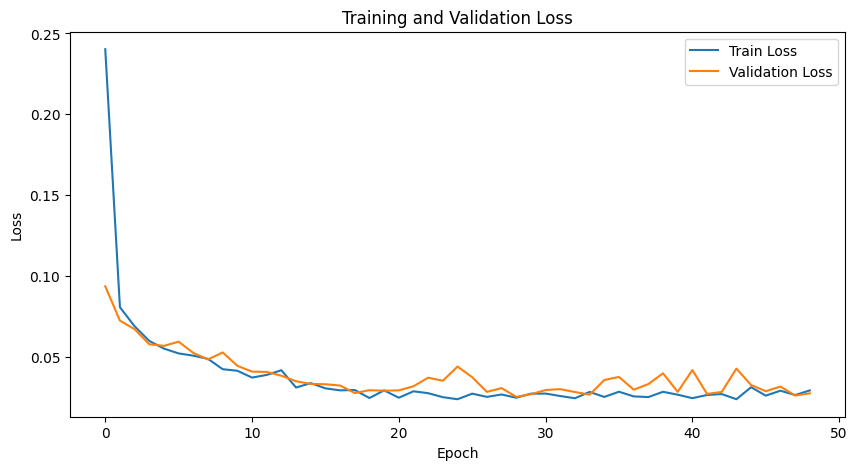

In [26]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [27]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.2526,  0.8980, -0.0479,  ..., -0.0882, -0.2700,  0.0134],
        [ 0.3713, -0.1554, -0.4222,  ..., -1.9491,  0.3399, -0.5892],
        [-0.3621, -0.2009, -0.1770,  ..., -1.2430,  0.1321, -0.0301],
        ...,
        [ 1.0784,  0.0047, -0.3806,  ..., -1.1766, -0.7262,  0.1084],
        [ 0.3838, -0.4928, -0.4163,  ...,  0.1950, -0.2916, -0.1260],
        [ 0.1540,  0.3349, -0.1327,  ...,  0.5256, -0.0536, -0.2010]],
       device='cuda:0')
Learned biases: tensor([ 0.2759,  0.2372,  0.2460,  0.0583, -0.2423, -0.1875, -0.0688,  0.3449,
         0.2028,  0.4601,  0.1370, -0.3110, -0.1748,  0.0507,  0.3228,  0.3119,
         0.0547, -0.0446, -0.4796,  0.4431,  0.1060, -0.1388,  0.3348, -0.1858,
        -0.0318, -0.1478, -0.2189,  0.0916, -0.6821,  0.2911,  0.3469,  0.4258,
        -0.0724,  0.3628,  0.1581,  0.4071,  0.5784,  0.5172,  0.1357, -0.0439,
         0.3953,  0.0829,  0.2791,  0.1875,  0.1406,  0.2447,  0.6896,  0.2173,
         0.4467,  0.2039,  0.

In [28]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1656 seconds to execute.
The function took 0.0609 seconds to execute.
The function took 0.0563 seconds to execute.
Train Accuracy: 99.4917
Validation Accuracy: 99.5060
Test Accuracy: 99.4631


###  S3 – learning rate far too low

In [29]:
hidden_width = 64
activation_function = nn.ReLU
batch_size = 64
epochs = 100
learning_rate = 5e-7 # <-------
optimizer = optim.AdamW
loss = nn.CrossEntropyLoss
min_delta = 0.00001
patience = 20

In [30]:
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [31]:
# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [32]:
# Initialize the model, loss function, and optimizer
n_features = X_train_tensor.shape[1]
n_classes = 4
model = ffnn(n_features, n_classes)
model = model.to(device)
criterion = loss()
optimizer = optimizer(model.parameters(), lr=learning_rate)

Epoch 20/100, Train Loss: 1.4417, Val Loss: 1.4404
Epoch 40/100, Train Loss: 1.4045, Val Loss: 1.4033
Epoch 60/100, Train Loss: 1.3682, Val Loss: 1.3670
Epoch 80/100, Train Loss: 1.3326, Val Loss: 1.3315
Epoch 100/100, Train Loss: 1.2978, Val Loss: 1.2968
The function took 47.8699 seconds to execute.


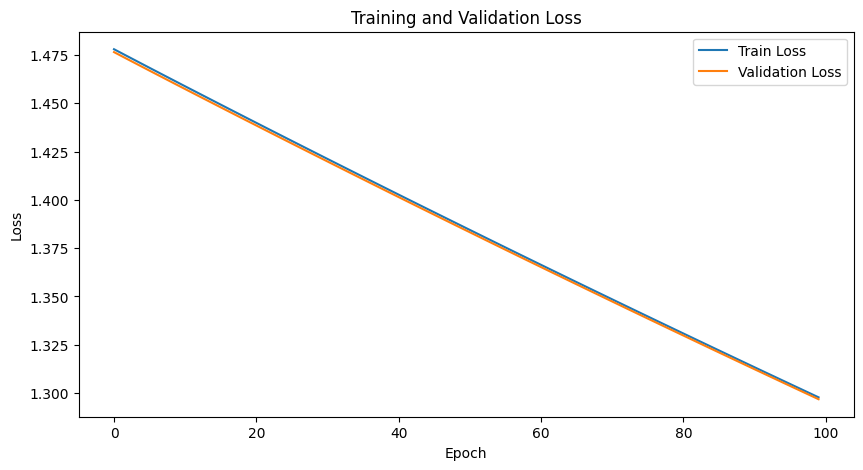

In [33]:
training_loop(model, train_loader, val_loader, train_dataset, val_dataset, device, optimizer, criterion, epochs, min_delta, patience)

In [34]:
# Inspecting the learned weights and biases
print(f'Learned weights: {model.fc1.weight.data}')
print(f'Learned biases: {model.fc1.bias.data}')
print(f'Learned weights: {model.fc2.weight.data}')
print(f'Learned biases: {model.fc2.bias.data}')

Learned weights: tensor([[ 0.1571,  0.1976,  0.1267,  ...,  0.1578, -0.1419,  0.2089],
        [ 0.1285,  0.0998, -0.2177,  ...,  0.1281,  0.1516, -0.1734],
        [-0.0337, -0.0918, -0.0962,  ..., -0.2129, -0.0855, -0.0899],
        ...,
        [-0.2093,  0.0398, -0.2241,  ...,  0.1769, -0.1102, -0.0315],
        [ 0.0720,  0.2433, -0.0583,  ..., -0.1302,  0.1191, -0.2467],
        [-0.1186,  0.1562, -0.0929,  ..., -0.0133,  0.0676, -0.1810]],
       device='cuda:0')
Learned biases: tensor([-0.0983, -0.2037, -0.0585, -0.0738, -0.2405,  0.1484, -0.0417,  0.0856,
         0.0362,  0.0429,  0.2296, -0.1277, -0.0598,  0.2002,  0.2182,  0.1867,
         0.1049, -0.0680, -0.0825,  0.2116, -0.0674, -0.0849,  0.0798, -0.1281,
         0.1287,  0.1548, -0.2502, -0.1738, -0.2002, -0.1554, -0.0962, -0.0734,
         0.1656,  0.0093, -0.2102,  0.0499, -0.1188, -0.1106, -0.2416,  0.1920,
         0.0270, -0.2299, -0.2197,  0.0082, -0.2513,  0.0894, -0.1345,  0.1531,
        -0.1283,  0.0523, -0.

In [35]:
train_accuracy = testing_model(model,train_loader,device)
val_accuracy = testing_model(model,val_loader,device)
test_accuracy = testing_model(model,test_loader,device)

print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

The function took 0.1750 seconds to execute.
The function took 0.0782 seconds to execute.
The function took 0.0613 seconds to execute.
Train Accuracy: 51.7397
Validation Accuracy: 51.5679
Test Accuracy: 51.7612


# Task 3 – When a feature biases the model

In [40]:
X_test_port8080 = X_test.copy()
X_test_port8080[X_test_port8080[:,-1] == 80, -1] = 8080
X_test_S_port8080 = scaler.transform(X_test_port8080)
X_test_tensor_port8080 = torch.tensor(X_test_S_port8080, dtype=torch.float32)
test_dataset_port8080 = TensorDataset(X_test_tensor_port8080, y_test_tensor)
test_loader_port8080 = DataLoader(test_dataset_port8080, batch_size=batch_size, shuffle=False)
test_accuracy_port8080 = testing_model(model,test_loader_port8080,device)
print(f'Test Accuracy: {test_accuracy_port8080:.4f}')


The function took 0.1104 seconds to execute.
Test Accuracy: 52.0833


In [41]:
############ Cleaning ###################################################
columns_to_filter = [
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Packet Length Mean',
    'Destination Port'
]
mask = (data[columns_to_filter] != 0.0).all(axis=1)
column_filtered_data = data[mask].copy()

modified_size = column_filtered_data.shape

print(f"Column Filtered Data size = {modified_size}")

no_dup_data = column_filtered_data.drop_duplicates(keep="first")

print(f"data no duplicates = {no_dup_data.shape}")
numeric_cols = no_dup_data.select_dtypes(include=[np.number]).columns
is_infinite = np.isinf(no_dup_data[numeric_cols]).any(axis=1)

# Teniamo solo le righe che NON contengono infiniti
clean_data = no_dup_data[~is_infinite]

print(f"data no inf= {clean_data.shape}")


############ Encoding ######################################

label_encoder = LabelEncoder()
clean_data['Label'] = label_encoder.fit_transform(clean_data['Label'])

encoded_clean_data = clean_data.copy()

############# Split #####################################
## train = 60 %, validation = 20 % , test=20%
X = encoded_clean_data[['Flow Duration', 'Flow IAT Mean', 'Fwd PSH Flags',
       'Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Flow Bytes/s',
       'Down/Up Ratio', 'SYN Flag Count', 'Fwd Packet Length Mean',
       'Fwd IAT Std', 'Packet Length Mean', 'Fwd Packet Length Max',
       'Subflow Fwd Packets', 'Flow Packets/s', 'Total Fwd Packets'
       ]].values
y = encoded_clean_data['Label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#################### Scaling ################################################
scaler = StandardScaler()
X_train_S = scaler.fit_transform(X_train)
X_val_S = scaler.transform(X_val)
X_test_S = scaler.transform(X_test)

print(y_train)
X_train_tensor = torch.tensor(X_train_S, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_S, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_S, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

Column Filtered Data size = (23773, 17)
data no duplicates = (23280, 17)
data no inf= (23280, 17)
[2 3 0 ... 0 0 2]
